In [2]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
import sys
sys.path.append('../../pybeh')
sys.path.append('../../CourierReinstate1')
import cmlreaders as cml
from cmldask import CMLDask as da
from dask.distributed import wait, as_completed
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import xarray as xr
import pandas_to_pybeh as pb
import scipy as scp
import re
import math
import pickle
import gc
from scipy import stats
from ptsa.data.filters import ButterworthFilter, MorletWaveletFilter
from ptsa.data.timeseries import *
from statsmodels.stats.multitest import multipletests
from compute_scalp_features import create_baseline_events
from BehavioralFunctions import *

pd.options.display.max_rows = 100
pd.options.display.max_columns = 50
%matplotlib inline
import importlib
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
import mne
from mne_bids import BIDSPath, read_raw_bids

In [3]:
subjects = ['LTP606', 'LTP607', 'LTP609', 'LTP610', 'LTP612']
experiment = 'valuecourier'
bids_root = "/home1/maint/LTP_BIDS/"

In [4]:
# Convert to DataFrame
def fix_evs(full_evs):
    value_recalls = full_evs[full_evs.trial_type == "VALUE_RECALL"] 
    words = full_evs[full_evs.trial_type == "WORD"]
    rec_words = full_evs[full_evs.trial_type == "REC_WORD"]
    rec_vv_words = full_evs[full_evs.trial_type == "REC_WORD_VV"]

    # WORD --> storepointtype, recalled--> VALUE_RECALL, REC_WORD, REC_WORD_VV
    word_trial_to_storepointtype = words.set_index("trial")["storepointtype"].to_dict()
    word_trial_to_recalled = words.set_index("trial")["recalled"].to_dict()
    for event_type in ["VALUE_RECALL", "REC_WORD", "REC_WORD_VV"]:
        subset = full_evs[full_evs.trial_type == event_type]
        for idx, row in subset.iterrows():
            trial = row["trial"]
            if trial in word_trial_to_storepointtype:
                full_evs.at[idx, "storepointtype"] = word_trial_to_storepointtype[trial]
            if trial in word_trial_to_recalled:
                full_evs.at[idx, "recalled"] = word_trial_to_recalled[trial]

    # VALUE_RECALL --> actualvalue, valuerecall --> WORD, `REC_WORD`, REC_WORD_VV
    valuerecall_trial_to_actualvalue = value_recalls.set_index("trial")["actualvalue"].to_dict()
    valuerecall_trial_to_valuerecall = value_recalls.set_index("trial")["valuerecall"].to_dict()

    # --- Apply to multi-row event types ---
    for event_type in ["WORD", "REC_WORD", "REC_WORD_VV"]:
        subset = full_evs[full_evs.trial_type == event_type]
        for idx, row in subset.iterrows():
            trial = row["trial"]

            # actualvalue
            if trial in valuerecall_trial_to_actualvalue:
                full_evs.at[idx, "actualvalue"] = valuerecall_trial_to_actualvalue[trial]

            # valuerecall
            if trial in valuerecall_trial_to_valuerecall:
                full_evs.at[idx, "valuerecall"] = valuerecall_trial_to_valuerecall[trial]
                
    return full_evs

In [3]:
from mne_bids import BIDSPath, read_raw_bids

bids_path = BIDSPath(
    subject="LTP606",
    session="0",
    task="valuecourier",   # <-- FIXED: lowercase
    datatype="eeg",
    root=bids_root
)

raw = read_raw_bids(bids_path)

raw.set_channel_types({
    'EXG1': 'eog',
    'EXG2': 'eog',
    'EXG3': 'eog',
    'EXG4': 'eog',
    'EXG5': 'misc',
    'EXG6': 'misc',
    'EXG7': 'misc',
    'EXG8': 'misc',
})

events, event_id = mne.events_from_annotations(raw)

epochs = mne.Epochs(
    raw,
    events=events,
    event_id=event_id,
    tmin=-0.2,
    tmax=0.8,
    baseline=(None, 0),
    preload=True,
    event_repeated='merge',   # or 'merge' or 'warn'
)
print("sfreq:", epochs.info["sfreq"])
print("tmin,tmax:", epochs.tmin, epochs.tmax)
print("n_times:", len(epochs.times))
print("duration_s:", epochs.times[-1] - epochs.times[0])

Extracting EDF parameters from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_events.tsv.
Reading channel info from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_channels.tsv.
Reading electrode coords from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_space-CapTrak_electrodes.tsv.
Used Annotations descriptions: ['FINAL_COMPENSATION', 'POINTER_ON', 'PRACTICE_DELIVERY_END', 'PRACTICE_DELIVERY_START', 'PRACTICE_VALUE_RECALL', 'PRACTICE_WORD', 'REC_START', 'REC_STOP', 'REC_WORD', 'REC_WORD_VV', 'SESS_END', 'SESS_START', 'TL_END', 'TL_START', 'TRIAL_END', 'TRIAL_START', 'VALUE_RECALL', 'VIDEO_START', 'VIDEO_STOP', 'WORD', 'store mappings']
Multiple event values for single event times found. Creating new event value to reflect 

In [103]:
# get full events
full_evs = None
for sub in subjects:
    for session in range(6):
        try:
            bids_path = BIDSPath(
                subject=sub,
                session=str(session),
                task=experiment,  
                datatype="beh",
                extension=".tsv",
                root=bids_root
            )
            evs = pd.read_csv(bids_path.fpath, sep="\t")
            full_evs = evs if full_evs is None else pd.concat([full_evs, evs], ignore_index=True)
        except Exception as e:
            print(e)

cols = ["primacybuf", "recencybuf", "serialpos"]

for c in cols:
    full_evs[c] = (
        pd.to_numeric(full_evs[c], errors="coerce")  # make sure it's numeric, NaNs stay NaN
        .astype("Int64")                             # pandas nullable integer dtype
    )

[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP612/ses-1/beh/sub-LTP612_ses-1_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP612/ses-2/beh/sub-LTP612_ses-2_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP612/ses-3/beh/sub-LTP612_ses-3_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP612/ses-4/beh/sub-LTP612_ses-4_task-valuecourier'
[Errno 2] No such file or directory: '/home1/maint/LTP_BIDS/sub-LTP612/ses-5/beh/sub-LTP612_ses-5_task-valuecourier'


In [80]:
with open("all_items.txt") as f:
    pool_raw = [w.strip() for w in f if w.strip()]
if pool_raw and pool_raw[0].lower() == "word":
    pool_raw = pool_raw[1:]

pool = [w.upper() for w in pool_raw]
pool_map = {w: i+1 for i, w in enumerate(pool)}

full_evs["itemno"] = full_evs["item"].map(pool_map)
del full_evs

### Encoding

In [81]:
### MNE EXPECTS SECONDS
REL_START, REL_STOP = 200 /1000, 3000 /1000
BUFFER_MS = 1000 /1000
WIDTH = 6

FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64
ROI_ORDER = ['LAI','RAI','LAS','RAS','LPS','RPS','LPI','RPI']

def assign_roi(channel):
    roi_dict = {
        'LAS':['C24','C25','D2','D3','D4','D11','D12','D13'],
        'LAI':['C31','C32','D5','D6','D9','D10','D21','D22'],
        'LPS':['D29','A5','A6','A7','A8','A17','A18'],
        'LPI':['D30','D31','A9','A10','A11','A15','A16'],
        'RAS':['B30','B31','B32','C2','C3','C4','C11','C12'],
        'RAI':['B24','B25','B28','B29','C5','C6','C9','C10'],
        'RPS':['A30','A31','A32','B3','B4','B5','B13'],
        'RPI':['A28','A29','B6','B7','B8','B11','B12'],
    }
    for roi, chans in roi_dict.items():
        if channel in chans:
            return roi
    return None

In [82]:
df_idx = cml.get_data_index('ltp').query("experiment == 'ValueCourier'").copy()
if subjects is not None:
    df_idx = df_idx[df_idx['subject'].isin(subjects)]
subjects = sorted(df_idx.subject.unique())

In [83]:
def welch_t_from_agg(n1, sum1, sumsq1, n0, sum0, sumsq0):
    with np.errstate(divide='ignore', invalid='ignore'):
        m1 = sum1 / np.maximum(n1, 1)
        m0 = sum0 / np.maximum(n0, 1)
        v1 = (sumsq1 - (sum1**2)/np.maximum(n1, 1)) / np.maximum(n1 - 1, 1)
        v0 = (sumsq0 - (sum0**2)/np.maximum(n0, 1)) / np.maximum(n0 - 1, 1)
        denom = np.sqrt(v1 / np.maximum(n1, 1) + v0 / np.maximum(n0, 1))
        t = (m1 - m0) / denom
        t[~np.isfinite(t)] = np.nan
    return t

In [84]:
from mne_bids import get_entity_vals

subjects = get_entity_vals(bids_root, "subject")
subject_root = os.path.join(bids_root, f"sub-{subjects[0]}")
sessions = get_entity_vals(subject_root, "session")
# tasks    = get_entity_vals(bids_root, "task")

In [85]:
sessions

['0', '1', '2', '3', '4', '5']

In [86]:
subjects

['LTP606', 'LTP607', 'LTP609', 'LTP610', 'LTP612', 'LTP613', 'LTP614']

In [87]:
# import os, gc
# import numpy as np
# import pandas as pd
# import xarray as xr
# import mne
# from collections import defaultdict
# from mne_bids import BIDSPath, read_raw_bids, get_entity_vals

# def _align_events_tsv_to_epochs(evs_all, epochs, *, sample_col="sample", raw_first_samp=0):
#     epoch_samples_abs = epochs.events[:, 0].astype(np.int64) + int(raw_first_samp)

#     sample_to_epoch_idxs = defaultdict(list)
#     for ei, s in enumerate(epoch_samples_abs):
#         sample_to_epoch_idxs[int(s)].append(ei)

#     keep_rows, keep_epoch = [], []
#     ev_samples = evs_all[sample_col].astype(np.int64).to_numpy()

#     for row_i, s in enumerate(ev_samples):
#         lst = sample_to_epoch_idxs.get(int(s), [])
#         if lst:
#             keep_rows.append(row_i)
#             keep_epoch.append(lst.pop(0))

#     evs_aligned = evs_all.iloc[keep_rows].reset_index(drop=True)
#     epochs_aligned = epochs[keep_epoch]   # safe; doesn't need preload
#     return evs_aligned, epochs_aligned


# def process_subject_stats(subject, exp, batch):
#     # ---- sessions for this subject ----
#     subject_root = os.path.join(bids_root, f"sub-{subject}")
#     sessions = sorted(get_entity_vals(subject_root, "session"), key=lambda s: int(s))

#     n1, n0 = {}, {}
#     sum1, sum0 = {}, {}
#     sumsq1, sumsq0 = {}, {}
#     freq_vec = FREQS

#     for sess in sessions:
#         try:
#             # --------------------------
#             # Build BIDSPath (use keyword args; avoid positional confusion)
#             # --------------------------
#             bids_path = BIDSPath(
#                 subject=subject,
#                 session=str(sess),
#                 task=exp,
#                 datatype="eeg",
#                 root=bids_root,
#             )

#             # --------------------------
#             # Load events.tsv
#             # --------------------------
#             events_path = os.path.join(bids_path.directory, bids_path.basename + "_events.tsv")
#             evs_all = pd.read_csv(events_path, sep="\t")
#             evs_all = fix_evs(evs_all)

#             # Must have these columns
#             if "trial_type" not in evs_all.columns or "sample" not in evs_all.columns:
#                 raise ValueError(f"events.tsv missing required columns. Have: {list(evs_all.columns)}")

#             # Match old selection as closely as possible
#             evs_all = evs_all.query("trial_type == 'WORD' and sample >= 0").copy()
#             if evs_all.empty:
#                 continue

#             # --------------------------
#             # Load raw via MNE-BIDS
#             # --------------------------
#             raw = read_raw_bids(bids_path)

#             raw.set_channel_types({
#                 'EXG1': 'eog', 'EXG2': 'eog', 'EXG3': 'eog', 'EXG4': 'eog',
#                 'EXG5': 'misc','EXG6': 'misc','EXG7': 'misc','EXG8': 'misc',
#             })

#             # --------------------------
#             # Build WORD-only epochs from annotations
#             # --------------------------
#             events, event_id = mne.events_from_annotations(raw)

#             # Keep only annotations corresponding to WORD
#             word_event_id = {k: v for k, v in event_id.items() if k == "WORD" or "WORD" in k}
#             if not word_event_id:
#                 continue

#             # Convert ms -> seconds for MNE
#             tmin = -BUFFER_MS
#             tmax = (REL_STOP + BUFFER_MS)

#             epochs = mne.Epochs(
#                 raw,
#                 events=events,
#                 event_id=word_event_id,
#                 tmin=tmin,
#                 tmax=tmax,
#                 baseline=(None, 0),
#                 preload=False,
#                 event_repeated="merge",
#             )

#             # EEG picks (exclude eog/misc)
#             picks_eeg = mne.pick_types(epochs.info, eeg=True, eog=False, misc=False)

#             # --------------------------
#             # Align events.tsv rows to epochs by sample
#             # --------------------------
#             evs_all, epochs = _align_events_tsv_to_epochs(evs_all, epochs, sample_col="sample", raw_first_samp=raw.first_samp)

#             if len(evs_all) == 0 or len(epochs.events) == 0:
#                 continue

#             assert np.all(
#                 evs_all["sample"].astype(np.int64).to_numpy()
#                 == (epochs.events[:, 0].astype(np.int64) + int(raw.first_samp))
#             ), "events.tsv and epochs are misaligned"

#             # --------------------------
#             # Batch loop (indices now match)
#             # --------------------------
#             rel_start_s = REL_START
#             rel_stop_s  = REL_STOP

#             for start in range(0, len(evs_all), batch):
#                 evs = evs_all.iloc[start:start + batch]
#                 rec_mask = evs["recalled"].to_numpy().astype(bool)

#                 ep = epochs[start:start + len(evs)]

#                 # Load only this batch's EEG data (float32 to reduce RAM)
#                 data = ep.get_data(picks=picks_eeg).astype(np.float32, copy=False)

#                 sfreq = float(ep.info["sfreq"])
#                 times = ep.times  # seconds
#                 ch_names = np.array([ep.ch_names[i] for i in picks_eeg], dtype=object)

#                 eeg = xr.DataArray(
#                     data,
#                     dims=("event", "channel", "time"),
#                     coords=dict(
#                         event=np.arange(len(evs), dtype=np.int32),
#                         channel=ch_names,
#                         time=times,
#                         samplerate=sfreq,
#                     ),
#                     name="eeg",
#                 )
#                 del data  # keep epochs/raw alive

#                 # PTSA-like filters
#                 eeg = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type="stop", order=4).filter(eeg)
#                 mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output="power", complete=True)
#                 pwr = mw.filter(eeg).sel(time=slice(rel_start_s, rel_stop_s)).mean(dim="time")

#                 # p: (event, channel, frequency)
#                 p = pwr.transpose("event", "channel", "frequency").values
#                 chans = pwr["channel"].values

#                 # init accumulators lazily
#                 for ch in chans:
#                     if ch not in n1:
#                         z = np.zeros(len(freq_vec), dtype=np.float64)
#                         n1[ch] = 0; n0[ch] = 0
#                         sum1[ch] = z.copy(); sum0[ch] = z.copy()
#                         sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()

#                 if rec_mask.any():
#                     vals = p[rec_mask]
#                     s = vals.sum(axis=0)
#                     ss = (vals ** 2).sum(axis=0)
#                     cnt = int(rec_mask.sum())
#                     for ci, ch in enumerate(chans):
#                         sum1[ch]   += s[ci]
#                         sumsq1[ch] += ss[ci]
#                         n1[ch]     += cnt

#                 nrec_mask = ~rec_mask
#                 if nrec_mask.any():
#                     vals = p[nrec_mask]
#                     s = vals.sum(axis=0)
#                     ss = (vals ** 2).sum(axis=0)
#                     cnt = int(nrec_mask.sum())
#                     for ci, ch in enumerate(chans):
#                         sum0[ch]   += s[ci]
#                         sumsq0[ch] += ss[ci]
#                         n0[ch]     += cnt

#                 del eeg, pwr, p
#                 gc.collect()

#             # cleanup per session
#             del epochs, raw
#             gc.collect()

#         except Exception as e:
#             print(f"[WARN] {subject} session {sess} skipped: {e}")
#             continue

#     if not n1:
#         return pd.DataFrame(columns=["subject", "channel", "frequency", "t"])

#     chans_sorted = sorted(n1.keys())
#     C, F = len(chans_sorted), len(freq_vec)

#     N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
#     S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
#     SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

#     for i, ch in enumerate(chans_sorted):
#         N1[i, :]  = n1[ch];        N0[i, :]  = n0[ch]
#         S1[i, :]  = sum1[ch];      S0[i, :]  = sum0[ch]
#         SS1[i, :] = sumsq1[ch];    SS0[i, :] = sumsq0[ch]

#     t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)

#     df = (
#         pd.DataFrame(
#             t_cf.reshape(-1),
#             index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=["channel", "frequency"]),
#             columns=["t"],
#         )
#         .reset_index()
#     )
#     df["subject"] = subject
#     return df


In [88]:
### USING MNE EPOCHS

import os, gc
import numpy as np
import pandas as pd
import mne
from collections import defaultdict
from mne_bids import BIDSPath, read_raw_bids, get_entity_vals

# IMPORTANT: use your already-written class
from ptsa.data.timeseries import TimeSeries  # <-- adjust import path if yours differs


def _align_events_tsv_to_epochs(evs_all, epochs, *, sample_col="sample", raw_first_samp=0):
    """
    Align events.tsv rows to epochs by absolute sample index.
    events.tsv 'sample' is assumed to be ABSOLUTE sample in raw file.

    Returns evs_aligned, epochs_aligned
    """
    # epochs.events[:,0] is sample index relative to raw.first_samp
    epoch_samples_abs = epochs.events[:, 0].astype(np.int64) + int(raw_first_samp)

    sample_to_epoch_idxs = defaultdict(list)
    for ei, s in enumerate(epoch_samples_abs):
        sample_to_epoch_idxs[int(s)].append(ei)

    keep_rows, keep_epoch = [], []
    ev_samples = evs_all[sample_col].astype(np.int64).to_numpy()

    for row_i, s in enumerate(ev_samples):
        lst = sample_to_epoch_idxs.get(int(s), [])
        if lst:
            keep_rows.append(row_i)
            keep_epoch.append(lst.pop(0))

    evs_aligned = evs_all.iloc[keep_rows].reset_index(drop=True)
    epochs_aligned = epochs[keep_epoch]
    return evs_aligned, epochs_aligned


def process_subject_stats(subject, exp, batch):
    # --- sessions for this subject ---
    subject_root = os.path.join(bids_root, f"sub-{subject}")
    sessions = sorted(get_entity_vals(subject_root, "session"), key=lambda s: int(s))

    n1, n0 = {}, {}
    sum1, sum0 = {}, {}
    sumsq1, sumsq0 = {}, {}
    freq_vec = FREQS

    for sess in sessions:
        try:
            bids_path = BIDSPath(
                subject=subject,
                session=str(sess),
                task=exp,
                datatype="eeg",
                root=bids_root,
            )

            # --------------------------
            # Load BIDS events.tsv
            # --------------------------
            events_path = os.path.join(bids_path.directory, bids_path.basename + "_events.tsv")
            evs_all = pd.read_csv(events_path, sep="\t")
            evs_all = fix_evs(evs_all)

            # must exist
            if "trial_type" not in evs_all.columns or "sample" not in evs_all.columns:
                raise ValueError(f"events.tsv missing required cols. Have: {list(evs_all.columns)}")

            # mimic old: keep WORD events only (and valid sample)
            evs_all = evs_all.query("trial_type == 'WORD' and sample >= 0").copy()
            if evs_all.empty:
                continue

            if "recalled" not in evs_all.columns:
                raise ValueError("events.tsv missing 'recalled' column (needed for rec_mask)")

            # --------------------------
            # Load raw
            # --------------------------
            raw = read_raw_bids(bids_path)

            raw.set_channel_types({
                "EXG1": "eog", "EXG2": "eog", "EXG3": "eog", "EXG4": "eog",
                "EXG5": "misc", "EXG6": "misc", "EXG7": "misc", "EXG8": "misc",
            })

            # --------------------------
            # Epoch WORD events from annotations
            # --------------------------
            events, event_id = mne.events_from_annotations(raw)
            word_event_id = {k: v for k, v in event_id.items() if (k == "WORD")}
            if not word_event_id:
                continue

            # ---- CRITICAL: MNE expects SECONDS ----
            # If your constants are in ms, convert here:
            tmin = (-BUFFER_MS)
            tmax = ((REL_STOP + BUFFER_MS))

            epochs = mne.Epochs(
                raw,
                events=events,
                event_id=word_event_id,
                tmin=tmin,
                tmax=tmax,
                baseline=(None, 0),
                preload=True,
                event_repeated="merge",
            )
            print("sfreq:", epochs.info["sfreq"])
            print("tmin,tmax:", epochs.tmin, epochs.tmax)
            print("n_times:", len(epochs.times))
            print("duration_s:", epochs.times[-1] - epochs.times[0])

            # We only need EEG channels (exclude eog/misc)
            picks_eeg = mne.pick_types(epochs.info, eeg=True, eog=False, misc=False)
            epochs = epochs.pick(picks_eeg)

            # --------------------------
            # Align evs_all to epochs by sample
            # --------------------------
            evs_all, epochs = _align_events_tsv_to_epochs(
                evs_all, epochs, sample_col="sample", raw_first_samp=raw.first_samp
            )
            
           

            if len(evs_all) == 0 or len(epochs.events) == 0:
                continue

            # sanity check (absolute sample match)
            assert np.all(
                evs_all["sample"].astype(np.int64).to_numpy()
                == (epochs.events[:, 0].astype(np.int64) + int(raw.first_samp))
            ), "events.tsv and epochs misaligned"

            # time slice also in seconds
            rel_start_s = REL_START
            rel_stop_s  = REL_STOP

            # --------------------------
            # Batch loop
            # --------------------------
            for start in range(0, len(evs_all), batch):
                event_df = evs_all.iloc[start:start + batch].reset_index(drop=True)
                rec_mask = event_df["recalled"].to_numpy().astype(bool)

                ep = epochs[start:start + len(event_df)]

                # Build PTSA TimeSeries exactly like old to_ptsa()
                eeg = TimeSeries.from_mne_epochs(ep, event_df)

                # reduce RAM like you wanted
                # eeg = eeg.astype(np.float32)

                # PTSA pipeline (same as old)
                eeg = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type="stop", order=4).filter(eeg)
                mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output="power", complete=True)
                pwr = mw.filter(eeg).sel(time=slice(rel_start_s, rel_stop_s)).mean(dim="time")

                p = pwr.transpose("event", "channel", "frequency").values
                chans = pwr["channel"].values

                for ch in chans:
                    if ch not in n1:
                        z = np.zeros(len(freq_vec), dtype=np.float64)
                        n1[ch] = 0; n0[ch] = 0
                        sum1[ch] = z.copy(); sum0[ch] = z.copy()
                        sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()

                if rec_mask.any():
                    vals = p[rec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals ** 2).sum(axis=0)
                    cnt = int(rec_mask.sum())
                    for ci, ch in enumerate(chans):
                        sum1[ch]   += s[ci]
                        sumsq1[ch] += ss[ci]
                        n1[ch]     += cnt

                nrec_mask = ~rec_mask
                if nrec_mask.any():
                    vals = p[nrec_mask]
                    s = vals.sum(axis=0)
                    ss = (vals ** 2).sum(axis=0)
                    cnt = int(nrec_mask.sum())
                    for ci, ch in enumerate(chans):
                        sum0[ch]   += s[ci]
                        sumsq0[ch] += ss[ci]
                        n0[ch]     += cnt

                del eeg, pwr, p
                gc.collect()

            del epochs, raw
            gc.collect()

        except Exception as e:
            print(f"[WARN] {subject} session {sess} skipped: {e}")
            continue

    if not n1:
        return pd.DataFrame(columns=["subject", "channel", "frequency", "t"])

    chans_sorted = sorted(n1.keys())
    C, F = len(chans_sorted), len(freq_vec)

    N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
    S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
    SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

    for i, ch in enumerate(chans_sorted):
        N1[i, :]  = n1[ch];       N0[i, :]  = n0[ch]
        S1[i, :]  = sum1[ch];     S0[i, :]  = sum0[ch]
        SS1[i, :] = sumsq1[ch];   SS0[i, :] = sumsq0[ch]

    t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)

    df = (
        pd.DataFrame(
            t_cf.reshape(-1),
            index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=["channel", "frequency"]),
            columns=["t"],
        )
        .reset_index()
    )
    df["subject"] = subject
    return df


In [89]:
# ### NOT USING EPOCHS

# import os, gc
# from collections import defaultdict

# import numpy as np
# import pandas as pd
# import mne
# from mne_bids import BIDSPath, read_raw_bids, get_entity_vals

# # assumes you already have these in scope (same as old script):
# # bids_root, fix_evs, FREQS, WIDTH, NOTCH_BAND, BUFFER_MS, REL_START, REL_STOP
# # ButterworthFilter, MorletWaveletFilter, welch_t_from_agg, TimeSeries


# def _get_subject_sessions(bids_root, subject):
#     """Return sorted session strings for sub-<subject>."""
#     subject_root = os.path.join(bids_root, f"sub-{subject}")
#     sess = get_entity_vals(subject_root, "session")
#     # sessions can be strings like "0","1",...; sort numerically when possible
#     try:
#         sess = sorted(sess, key=lambda s: int(s))
#     except Exception:
#         sess = sorted(sess)
#     return sess


# def _ensure_seconds(x, assume_ms=True):
#     """Convert scalar or array-like to seconds if assume_ms."""
#     return (np.asarray(x, dtype=float) / 1000.0) if assume_ms else np.asarray(x, dtype=float)


# def process_subject_stats(subject, exp, batch, *, assume_ms=True):
#     """
#     BIDS/MNE replacement for the old CMLReader+load_eeg(...).to_ptsa() pipeline.

#     Key behavior:
#       - loads events.tsv first
#       - opens Raw without preloading full data
#       - per batch, loads only the needed windows via raw.get_data(start/stop)
#       - builds PTSA TimeSeries with event MultiIndex (like to_ptsa)
#       - uses your same Butterworth + Morlet + aggregation logic
#     """
#     sessions = _get_subject_sessions(bids_root, subject)

#     n1, n0 = {}, {}
#     sum1, sum0 = {}, {}
#     sumsq1, sumsq0 = {}, {}
#     freq_vec = FREQS

#     # --- time handling (MNE raw time is seconds) ---
#     # If your constants are actually in seconds already, call with assume_ms=False
#     tmin_s = float(_ensure_seconds(-BUFFER_MS, assume_ms=assume_ms))
#     tmax_s = float(_ensure_seconds(REL_STOP + BUFFER_MS, assume_ms=assume_ms))
#     rel_start_s = float(_ensure_seconds(REL_START, assume_ms=assume_ms))
#     rel_stop_s  = float(_ensure_seconds(REL_STOP, assume_ms=assume_ms))

#     for sess in sessions:
#         try:
#             # --------------------------
#             # Build BIDSPath
#             # --------------------------
#             bids_path = BIDSPath(
#                 subject=subject,
#                 session=str(sess),
#                 task=exp,
#                 datatype="eeg",
#                 root=bids_root,
#             )

#             # --------------------------
#             # Load BIDS events.tsv FIRST
#             # --------------------------
#             events_path = os.path.join(bids_path.directory, bids_path.basename + "_events.tsv")
#             evs_all = pd.read_csv(events_path, sep="\t")
#             evs_all = fix_evs(evs_all)

#             # Must exist for alignment & masks
#             required = {"trial_type", "sample", "recalled"}
#             missing = required - set(evs_all.columns)
#             if missing:
#                 raise ValueError(f"events.tsv missing columns {missing}. Have: {list(evs_all.columns)}")

#             # Mimic old: keep WORD & valid sample
#             evs_all = evs_all.query("trial_type == 'WORD' and sample >= 0").copy()
#             if evs_all.empty:
#                 continue

#             # --------------------------
#             # Load Raw (no full preload)
#             # --------------------------
#             raw = read_raw_bids(bids_path)

#             # channel typing like you had
#             raw.set_channel_types({
#                 "EXG1": "eog", "EXG2": "eog", "EXG3": "eog", "EXG4": "eog",
#                 "EXG5": "misc", "EXG6": "misc", "EXG7": "misc", "EXG8": "misc",
#             })

#             sfreq = float(raw.info["sfreq"])

#             # EEG-only channels (exclude eog/misc)
#             picks_eeg = mne.pick_types(raw.info, eeg=True, eog=False, misc=False)
#             if len(picks_eeg) == 0:
#                 continue
#             ch_names = np.array([raw.ch_names[p] for p in picks_eeg], dtype=object)

#             # --------------------------
#             # Align events.tsv samples to raw timebase
#             # --------------------------
#             # BIDS 'sample' is absolute sample index; raw.get_data uses sample indices relative to raw.first_samp.
#             ev_samples_abs = evs_all["sample"].astype(np.int64).to_numpy()
#             ev_samples_rel = ev_samples_abs - int(raw.first_samp)

#             # Drop events that are clearly out of bounds for the epoch window
#             n_samp = int(round((tmax_s - tmin_s) * sfreq)) + 1
#             beg = (ev_samples_rel + int(round(tmin_s * sfreq))).astype(np.int64)
#             end = beg + n_samp
#             ok = (beg >= 0) & (end <= raw.n_times)

#             evs_all = evs_all.loc[ok].reset_index(drop=True)
#             ev_samples_rel = ev_samples_rel[ok]

#             if len(evs_all) == 0:
#                 continue

#             # Build per-epoch time axis in seconds (matches PTSA expectation)
#             times = tmin_s + np.arange(n_samp) / sfreq

#             # --------------------------
#             # Batch loop (load only needed EEG windows)
#             # --------------------------
#             for start in range(0, len(evs_all), batch):
#                 event_df = evs_all.iloc[start:start + batch].reset_index(drop=True)
#                 rec_mask = event_df["recalled"].to_numpy().astype(bool)

#                 batch_samples_rel = ev_samples_rel[start:start + len(event_df)]

#                 # allocate batch data in float32 for RAM
#                 data = np.empty((len(event_df), len(picks_eeg), n_samp), dtype=np.float32)

#                 for ei, s0 in enumerate(batch_samples_rel):
#                     beg_i = int(round(s0 + tmin_s * sfreq))
#                     end_i = beg_i + n_samp
#                     # these should be valid because of ok mask, but keep safe
#                     if beg_i < 0 or end_i > raw.n_times:
#                         data[ei, :, :] = np.nan
#                         continue

#                     seg = raw.get_data(picks=picks_eeg, start=beg_i, stop=end_i)  # (n_ch, n_samp)
#                     data[ei, :, :] = seg.astype(np.float32, copy=False)

#                 # drop any NaN rows (edge cases)
#                 good = np.isfinite(data).all(axis=(1, 2))
#                 if not good.any():
#                     del data
#                     continue

#                 if not good.all():
#                     data = data[good]
#                     event_df = event_df.loc[good].reset_index(drop=True)
#                     rec_mask = rec_mask[good]

#                 # PTSA-like TimeSeries with MultiIndex event axis (like old to_ptsa)
#                 eeg = TimeSeries.create(
#                     data,
#                     sfreq,
#                     dims=("event", "channel", "time"),
#                     coords={
#                         "event": pd.MultiIndex.from_frame(event_df),
#                         "channel": ch_names,
#                         "time": times,
#                     },
#                     name="eeg",
#                 )

#                 # --- same filters as old ---
#                 eeg = ButterworthFilter(freq_range=list(NOTCH_BAND), filt_type="stop", order=4).filter(eeg)
#                 mw = MorletWaveletFilter(freqs=freq_vec, width=WIDTH, output="power", complete=True)
#                 pwr = mw.filter(eeg).sel(time=slice(rel_start_s, rel_stop_s)).mean(dim="time")

#                 # shape: (event, channel, frequency)
#                 p = pwr.transpose("event", "channel", "frequency").values
#                 chans = pwr["channel"].values

#                 # init accumulators lazily (same as old)
#                 for ch in chans:
#                     if ch not in n1:
#                         z = np.zeros(len(freq_vec), dtype=np.float64)
#                         n1[ch] = 0; n0[ch] = 0
#                         sum1[ch] = z.copy(); sum0[ch] = z.copy()
#                         sumsq1[ch] = z.copy(); sumsq0[ch] = z.copy()

#                 if rec_mask.any():
#                     vals = p[rec_mask]
#                     s = vals.sum(axis=0)
#                     ss = (vals ** 2).sum(axis=0)
#                     cnt = int(rec_mask.sum())
#                     for ci, ch in enumerate(chans):
#                         sum1[ch]   += s[ci]
#                         sumsq1[ch] += ss[ci]
#                         n1[ch]     += cnt

#                 nrec_mask = ~rec_mask
#                 if nrec_mask.any():
#                     vals = p[nrec_mask]
#                     s = vals.sum(axis=0)
#                     ss = (vals ** 2).sum(axis=0)
#                     cnt = int(nrec_mask.sum())
#                     for ci, ch in enumerate(chans):
#                         sum0[ch]   += s[ci]
#                         sumsq0[ch] += ss[ci]
#                         n0[ch]     += cnt

#                 del eeg, pwr, p, data
#                 gc.collect()

#             # per-session cleanup
#             del raw
#             gc.collect()

#         except Exception as e:
#             print(f"[WARN] {subject} session {sess} skipped: {e}")
#             continue

#     # --------------------------
#     # Final t-stats (unchanged)
#     # --------------------------
#     if not n1:
#         return pd.DataFrame(columns=["subject", "channel", "frequency", "t"])

#     chans_sorted = sorted(n1.keys())
#     C, F = len(chans_sorted), len(freq_vec)

#     N1  = np.zeros((C, F));  N0  = np.zeros((C, F))
#     S1  = np.zeros((C, F));  S0  = np.zeros((C, F))
#     SS1 = np.zeros((C, F));  SS0 = np.zeros((C, F))

#     for i, ch in enumerate(chans_sorted):
#         N1[i, :]  = n1[ch];        N0[i, :]  = n0[ch]
#         S1[i, :]  = sum1[ch];      S0[i, :]  = sum0[ch]
#         SS1[i, :] = sumsq1[ch];    SS0[i, :] = sumsq0[ch]

#     t_cf = welch_t_from_agg(N1, S1, SS1, N0, S0, SS0)

#     df = (
#         pd.DataFrame(
#             t_cf.reshape(-1),
#             index=pd.MultiIndex.from_product([chans_sorted, freq_vec], names=["channel", "frequency"]),
#             columns=["t"],
#         )
#         .reset_index()
#     )
#     df["subject"] = subject
#     return df


In [90]:
# d = process_subject_stats("LTP606", "valuecourier", BATCH_EVENTS)

In [91]:
# d

In [92]:
client = da.new_dask_client_slurm(
    job_name="encoding",
    memory_per_job="100GB",
    max_n_jobs=10,
    queue="RAM",
    local_directory="~/scratch",
    log_directory=os.path.expanduser("~/log_directory")
)

Unique port for zrentala is 51618
{'dashboard_address': ':51618'}
To view the dashboard, run: 
`ssh -fN zrentala@rhino2.psych.upenn.edu -L 8000:192.168.86.142:43910` in your local computer's terminal (NOT rhino) 
and then navigate to localhost:8000 in your browser


In [93]:
subjects = ["LTP606"]
futures = [client.submit(process_subject_stats, s, experiment, BATCH_EVENTS) for s in subjects]

In [94]:
subj_chan_t_list, n_done, n_fail = [], 0, 0
for fut in as_completed(futures):
    try:
        df_sub = fut.result()
        subj_chan_t_list.append(df_sub)
        n_done += 1
        sub = df_sub['subject'].iat[0] if not df_sub.empty else 'EMPTY_SUBJECT'
        print(f"[DONE] {n_done}/{len(subjects)} :: {sub} (rows={len(df_sub)})")
    except Exception as e:
        n_fail += 1
        print(f"[ERR] Future failed ({n_fail} fails): {e}")

[DONE] 1/1 :: LTP606 (rows=5888)


In [95]:
client.shutdown()

In [96]:
chan_t_all = (pd.concat(subj_chan_t_list, ignore_index=True)
              if subj_chan_t_list else
              pd.DataFrame(columns=['subject','channel','frequency','t']))
chan_t_all['ROI'] = chan_t_all['channel'].map(assign_roi)
chan_t_all = chan_t_all.dropna(subset=['ROI']).copy()

subj_roi_t = (chan_t_all.groupby(['subject','ROI','frequency'], as_index=False)['t'].mean())

In [97]:
def one_samp(s):
    s = s.dropna()
    if s.empty: return pd.Series({'t_mean':np.nan,'p':np.nan})
    t_mean = s.mean()
    _, p = stats.ttest_1samp(s, 0.0, nan_policy='omit')
    return pd.Series({'t_mean':t_mean, 'p':p})

In [98]:
mean_tbl = (subj_roi_t
            .groupby(['ROI','frequency'], as_index=False)['t']
            .mean()
            .rename(columns={'t': 't_mean'}))

p_tbl_long = (subj_roi_t
              .groupby(['ROI','frequency'])['t']
              .apply(lambda s: stats.ttest_1samp(s.dropna(), 0.0)[1]
                     if s.notna().any() else np.nan)
              .reset_index(name='p'))

agg = mean_tbl.merge(p_tbl_long, on=['ROI','frequency'], how='outer')

heat = agg.pivot(index='frequency', columns='ROI', values='t_mean')
cols_present = [c for c in ROI_ORDER if c in heat.columns]
if cols_present:
    heat = heat[cols_present]

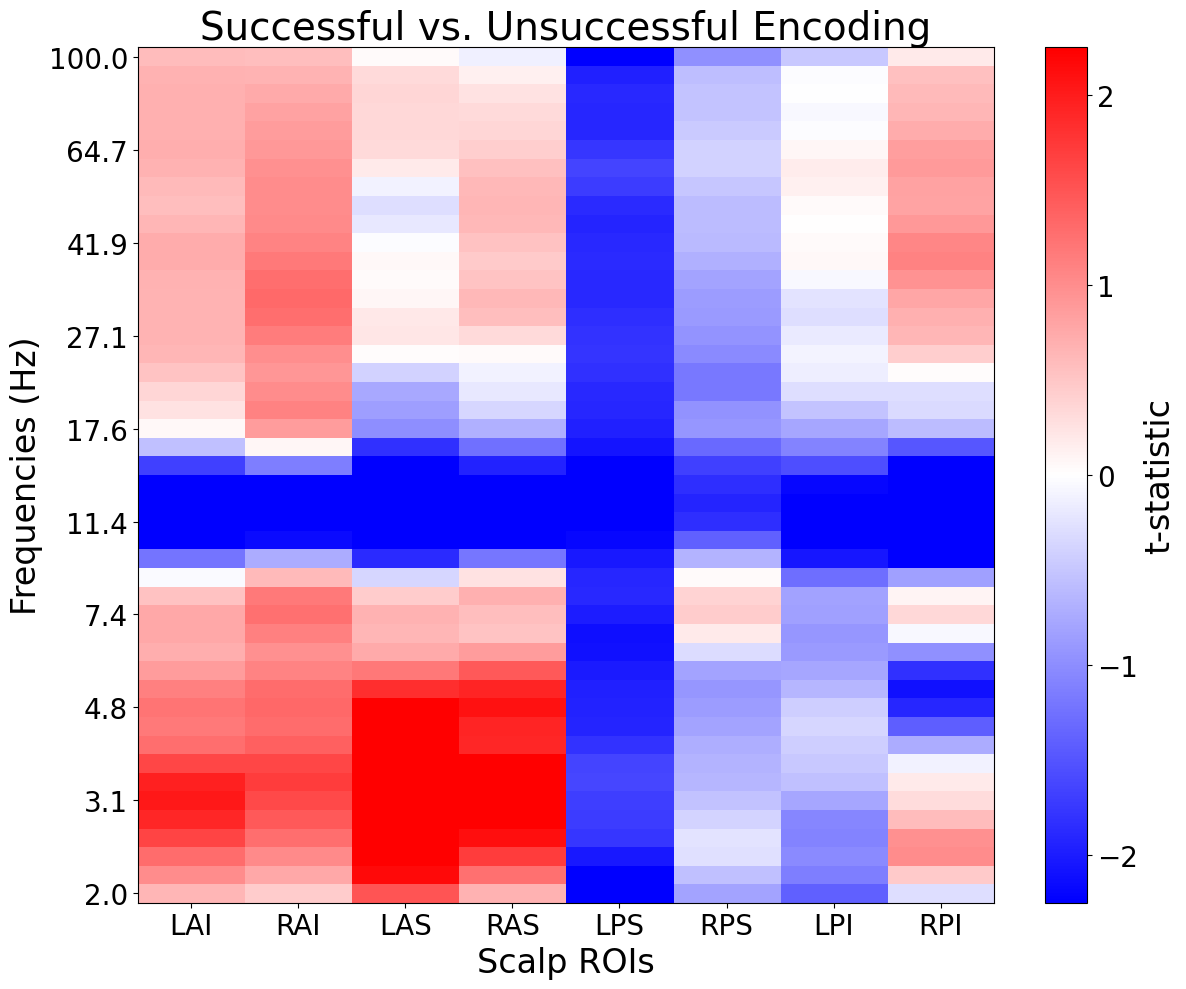

In [99]:
fig = plt.figure(figsize=(12, 10))
ax = plt.gca()
norm = mcolors.TwoSlopeNorm(vmin=-2.25, vcenter=0.0, vmax=2.25)
im = ax.imshow(heat, cmap='bwr', aspect='auto', norm=norm)

freqs = heat.index.values
tick_idx = np.unique(np.round(np.linspace(0, len(freqs)-1, 10)).astype(int))
ax.set_yticks(tick_idx)
ax.set_yticklabels([f'{freqs[i]:.1f}' for i in tick_idx], fontsize=20)

ax.set_xticks(range(heat.shape[1]))
ax.set_xticklabels(list(heat.columns), fontsize=20)

ax.set_xlabel('Scalp ROIs', fontsize=24)
ax.set_ylabel('Frequencies (Hz)', fontsize=24)
ax.set_title('Successful vs. Unsuccessful Encoding', fontsize=28)

cbar = plt.colorbar(im, ax=ax, fraction=.1)
cbar.set_label('t-statistic', size=24)
cbar.set_ticks([-2, -1, 0, 1, 2])
cbar.ax.tick_params(labelsize=20)

ax.invert_yaxis()
ax.grid(False)
plt.tight_layout()
plt.show()

In [27]:
### Check cml reader path

import os
import cmlreaders as cml

subject = "LTP606"
sess = 0
exp = "ValueCourier"

reader = cml.CMLReader(subject=subject, experiment=exp, session=sess)
evs_cml = reader.load("task_events")

# Most LTP task_events have eegfile; fall back to any column containing "eeg"
eeg_cols = [c for c in evs_cml.columns if "eeg" in c.lower()]
print("EEG-ish columns:", eeg_cols)

# Preferred
if "eegfile" in evs_cml.columns:
    eeg_path = evs_cml["eegfile"].dropna().iloc[0]
else:
    # fallback: pick first non-null from first eeg-ish column
    if not eeg_cols:
        raise RuntimeError("No EEG-related columns found in task_events.")
    col = eeg_cols[0]
    eeg_path = evs_cml[col].dropna().iloc[0]

print("EEG path from events:", eeg_path)

# If it's relative, make it absolute under reader.rootdir
if isinstance(eeg_path, str) and not eeg_path.startswith("/"):
    eeg_path = os.path.join(reader.rootdir, eeg_path)

print("EEG path (absolute):", eeg_path)


EEG-ish columns: ['eegoffset', 'eegfile']
EEG path from events: /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0.bdf
EEG path (absolute): /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0.bdf


In [5]:
sess = 0
subject = "LTP606"
### Compare BIDS vs CML Reader
bids_root = "/home1/maint/LTP_BIDS/"
# 1 subject
# events
# CML
reader = cml.CMLReader(subject=subject, experiment="ValueCourier", session=sess)
evs_cml = reader.load('task_events')
# evs_cml = fix_evs(evs_cml)
# evs_cml = evs_cml[(evs_cml['type']=='WORD') & (evs_cml['eegoffset']>=0)]

# BIDS
bids_path = BIDSPath(
    subject=subject,
    session=str(sess),
    task="valuecourier",
    datatype="eeg",
    root=bids_root,
)

# --------------------------
# Load BIDS events.tsv
# --------------------------
events_path = os.path.join(bids_path.directory, bids_path.basename + "_events.tsv")
evs_bids = pd.read_csv(events_path, sep="\t")
evs_bids = fix_evs(evs_bids)

# must exist
# if "trial_type" not in evs_bids.columns or "sample" not in evs_bids.columns:
#     raise ValueError(f"events.tsv missing required cols. Have: {list(evs_all.columns)}")

# mimic old: keep WORD events only (and valid sample)
# evs_bids = evs_bids.query("trial_type == 'WORD' and sample >= 0").copy()

In [6]:
# check eeg
# CML
REL_START, REL_STOP = 200, 3000
BUFFER_MS = 1000
WIDTH = 6

FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64
eeg_cml = reader.load_eeg().to_ptsa()

Extracting EDF parameters from /protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 10821631  =      0.000 ...  5284.000 secs...


In [ ]:
# bids
REL_START, REL_STOP = 200 /1000, 3000 /1000
BUFFER_MS = 1000 /1000
WIDTH = 6

FREQS = np.logspace(np.log10(2), np.log10(100), 46)
NOTCH_BAND = (58., 62.)
BATCH_EVENTS = 64

bids_path = BIDSPath(
    subject="LTP606",
    session=str(0),
    task="valuecourier",
    datatype="eeg",
    root=bids_root,
)

raw = read_raw_bids(bids_path)

raw.set_channel_types({
    "EXG1": "eog", "EXG2": "eog", "EXG3": "eog", "EXG4": "eog",
    "EXG5": "misc", "EXG6": "misc", "EXG7": "misc", "EXG8": "misc",
})

# raw.drop_channels(
#     [ch for ch in raw.ch_names if raw.get_channel_types(picks=ch)[0] != "eeg"]
# )

# --------------------------
# Epoch WORD events from annotations
# --------------------------
events, event_id = mne.events_from_annotations(raw)
word_event_id = {k: v for k, v in event_id.items() if (k == "WORD")}

# ---- CRITICAL: MNE expects SECONDS ----
# If your constants are in ms, convert here:
tmin = (-BUFFER_MS)
tmax = ((REL_STOP + BUFFER_MS))

epochs_bids = mne.Epochs(
    raw,
    events=events,
    event_id=word_event_id,
    tmin=tmin,
    tmax=tmax,
    baseline=(None, 0),
    preload=True,
    event_repeated="merge",
)
# epochs_bids = mne.Epochs(
#     raw,
#     events=events,
#     event_id=word_event_id,
#     tmin=tmin,
#     tmax=tmax,
#     baseline=(None, 0),
#     preload=True,
#     event_repeated="merge",
# )
print("sfreq:", epochs_bids.info["sfreq"])
print("tmin,tmax:", epochs_bids.tmin, epochs_bids.tmax)
print("n_times:", len(epochs_bids.times))
print("duration_s:", epochs_bids.times[-1] - epochs_bids.times[0])

eeg_bids = TimeSeries.from_mne_epochs(epochs_bids, evs_bids)
# # --------------------------
# # Align evs_all to epochs by sample
# # --------------------------
# evs_all, epochs = _align_events_tsv_to_epochs(
#     evs_all, epochs, sample_col="sample", raw_first_samp=raw.first_samp
# )


In [7]:
raw = read_raw_bids(
    bids_path,
    verbose=True,
)
sfreq = raw.info["sfreq"]
ch_names = raw.ch_names
times = raw.times  
eeg_bids = xr.DataArray(
    raw.get_data()[None, :, :],                           # -> (1, n_channels, n_times)
    dims=("event", "channel", "time"),         # match eeg_cml dim names
    coords={
        "event": [0],                          # singleton event index
        "channel": ch_names,
        "time": times,
        "samplerate": sfreq,                    # scalar coord (optional)
    },
    name="eeg",
)
del ch_names, times, sfreq

Extracting EDF parameters from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_events.tsv.
Reading channel info from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_channels.tsv.
Reading electrode coords from /home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_space-CapTrak_electrodes.tsv.


In [9]:
diff = eeg_cml.time - eeg_bids.time

In [20]:
eeg_cml.time

<xarray.TimeSeries 'time' (time: 10821632)>
array([0.000000e+00, 4.882812e-01, 9.765625e-01, ..., 5.283999e+06,
       5.283999e+06, 5.284000e+06])
Coordinates:
  * time        (time) float64 0.0 0.4883 0.9766 ... 5.284e+06 5.284e+06
    samplerate  float64 2.048e+03

In [21]:
eeg_bids.time

<xarray.DataArray 'time' (time: 10821632)>
array([0.000000e+00, 4.882812e-04, 9.765625e-04, ..., 5.283999e+03,
       5.283999e+03, 5.284000e+03])
Coordinates:
  * time        (time) float64 0.0 0.0004883 0.0009766 ... 5.284e+03 5.284e+03
    samplerate  float64 2.048e+03

In [ ]:
np.allclose(eeg_bids.values, eeg_cml.values, equal_nan=True)

In [9]:
import numpy as np
import xarray as xr
import pandas as pd
import pyedflib
from ReportRawEEG import *
# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------
bids_bdf_path = "/home1/maint/LTP_BIDS/sub-LTP606/ses-0/eeg/sub-LTP606_ses-0_task-valuecourier_eeg.bdf"
cml_bdf_path  = "/protocols/ltp/subjects/LTP606/experiments/ValueCourier/sessions/0/ephys/current_processed/LTP606_session_0.bdf"
eeg_pyedflib = load_bdf_as_xarray(cml_bdf_path)

Unknown or invalid physical unit 'boolean' 
for channel 136 (Status)


# Time dim is different due to floating point error because MNE uses seconds and CMLreader uses ms. After comparing on index and not time, BIDS and CMLReader show the same data

In [10]:
### COMPARE SOURCES GENERIC

import numpy as np
import xarray as xr
import pandas as pd

# Assumed available from your ReportRawEEG utilities:
# strip_event_metadata, summarize_channel_coords, report_mismatches, print_raw_data

# ----------------------------
# EXAMPLE CALL
# ----------------------------
df_stats, summary = compare_eeg_sources(
    eegs=[eeg_bids, eeg_cml, eeg_pyedflib],
    names=["BIDS", "CMLReader", "PYEDFLIB"]
)



================ CHANNEL SUMMARY (pre-compare; no alignment) ================

--- Channel coord check ---
BIDS #channels: 137
CML  #channels: 137
Common channels: 137
Channel order matches (on common channels).

--- Channel coord check ---
BIDS #channels: 137
CML  #channels: 137
Common channels: 137
Channel order matches (on common channels).

--- Channel coord check ---
BIDS #channels: 137
CML  #channels: 137
Common channels: 137
Channel order matches (on common channels).

================ PAIRWISE COMPARISONS (no alignment) ================
BIDS vs CMLReader: time lengths 10821632 vs 10821632 (comparing first 10821632 samples)
BIDS vs PYEDFLIB: time lengths 10821632 vs 10821632 (comparing first 10821632 samples)
CMLReader vs PYEDFLIB: time lengths 10821632 vs 10821632 (comparing first 10821632 samples)

================ PER-CHANNEL STATS (ALL PAIRS; no alignment) ================
           comparison channel  n_exact_diff  n_close_diff  mean_abs_diff  max_abs_diff  mean_signed_di

NameError: name 'SLICE_CFG' is not defined